### Initialization and Environment Setup

This cell initializes the AutoREACTER environment and prepares the working directory for the current run.

- `Initialization()` sets up the AutoREACTER runtime environment.
- `InputParser()` prepares the parser for validating and normalizing user input files.
- `GetCacheDir()` retrieves the staging cache directory used for intermediate data.
- `RunDirectoryManager.make_dated_run_dir()` creates a timestamped run directory to store outputs for this session.

This ensures each run is isolated and reproducible.

In [1]:
from AutoREACTER.initialization import Initialization
from AutoREACTER.input_parser import InputParser
from AutoREACTER.cache import GetCacheDir, RunDirectoryManager, RetentionCleanup
from AutoREACTER.detectors.functional_groups_detector import FunctionalGroupsDetector
from AutoREACTER.detectors.reaction_detector import ReactionDetector
from AutoREACTER.detectors.non_monomer_detector import NonReactantsDetector
# from AutoREACTER.reaction_template_builder.run_reaction_template_pipeline import ReactionTemplatePipeline
from rdkit import Chem
from rdkit.Chem import Draw
import json

Initialization()
input_parser = InputParser()
cache_dir = GetCacheDir().staging_dir
dated_cache_dir = RunDirectoryManager.make_dated_run_dir(cache_dir, chdir_to="none")
# #future use
# RunDirectoryManager.copy_into_run(cache_dir, dated_cache_dir)




All required modules are successfully imported.
                                                                                                                                                                                                                                                       
      .o.                       .                  ooooooooo.   oooooooooooo       .o.         .oooooo.   ooooooooooooo oooooooooooo ooooooooo.   
     .888.                    .o8                  `888   `Y88. `888'     `8      .888.       d8P'  `Y8b  8'   888   `8 `888'     `8 `888   `Y88. 
    .8"888.     oooo  oooo  .o888oo  .ooooo.        888   .d88'  888             .8"888.     888               888       888          888   .d88' 
   .8' `888.    `888  `888    888   d88' `88b       888ooo88P'   888oooo8       .8' `888.    888               888       888oooo8     888ooo88P'  
  .88ooo8888.    888   888    888   888   888       888`88b.     888    "      .88ooo8888.   888               888  

### Cache Cleanup (Optional)

This cell can be used to clean up cached data generated by previous runs.

- `RetentionCleanup.run()` removes cached directories from the AutoREACTER cache base directory.
- Useful for freeing disk space or resetting the cache state.

Uncomment and run only if you want to remove cached run data.

In [2]:
# RetentionCleanup.run(GetCacheDir().cache_base_dir)

### Load, Validate, and Visualize Monomers

This cell loads the example input file, validates it using the `InputParser`, and visualizes the monomers.

- The JSON input file is loaded into `input_data`.
- `validate_inputs()` checks the schema and normalizes the data.
- `molecule_representation_of_initial_molecules()` extracts RDKit molecule objects.
- `Draw.MolsToGridImage()` displays the monomers in a grid with their labels.

This provides a quick visual check of the input molecules before running further analysis.

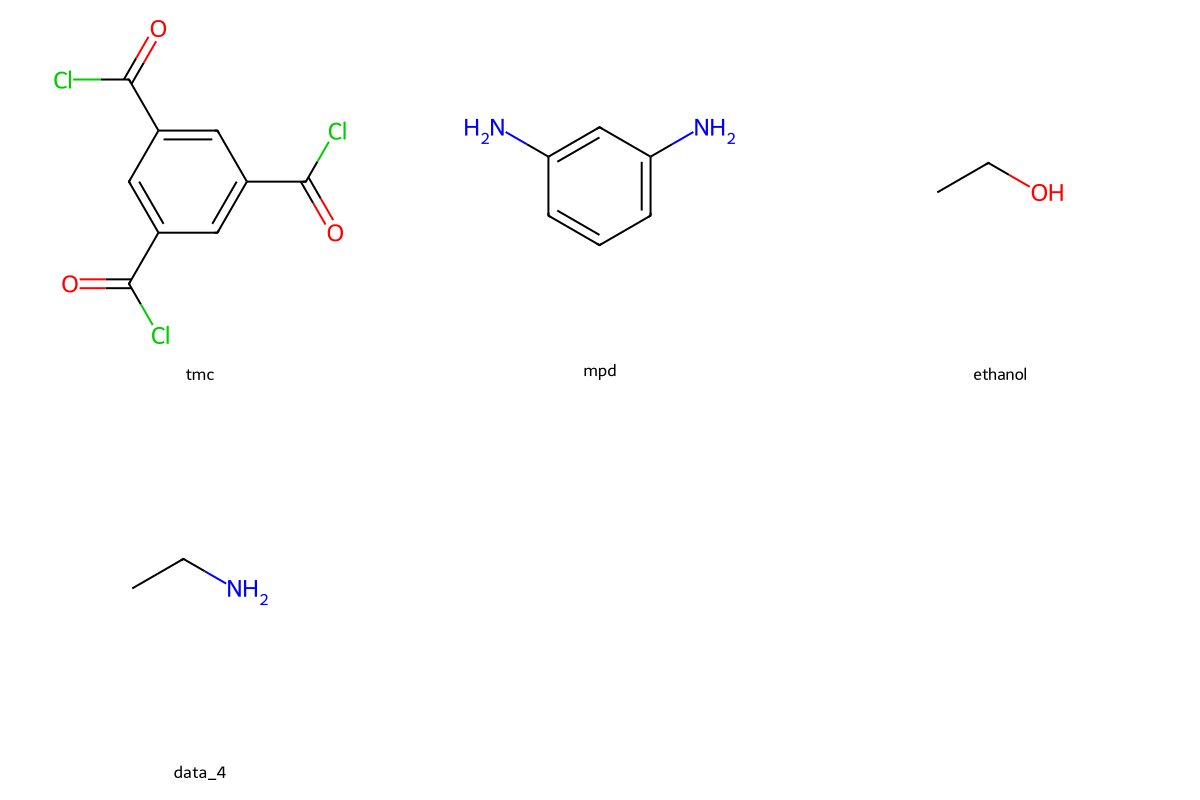

In [3]:
with open("example_1_inputs_count_mode.json", "r") as f:
    input_data = json.load(f)

validated_inputs = input_parser.validate_inputs(input_data)
initial_molecules = input_parser.initial_molecules_image_grid(validated_inputs)
initial_molecules

### Cache Directory Information

This cell prints the default AutoREACTER cache directory.

In [4]:
default_cache_dir = GetCacheDir().cache_base_dir
print(f"Default cache directory: {default_cache_dir}")

Default cache directory: /mnt/c/Users/Janitha/Documents/AutoREACTER/cache


### Functional Group Detection

This cell runs the functional group detection step.

- `FunctionalGroupsDetector()` initializes the detector.
- `functional_groups_detector()` analyzes the validated monomers.
- It identifies functional groups present in each molecule and generates corresponding visualization images.

In [5]:
# Run the detector only after the inputs have been validated, as it consumes validated_inputs.monomers to execute the detection workflow.
functional_groups_detector = FunctionalGroupsDetector()
functional_groups, functional_groups_imgs = \
    functional_groups_detector.functional_groups_detector(
        validated_inputs.monomers
    )

O=C(Cl)c1cc(C(=O)Cl)cc(C(=O)Cl)c1 has functionality: di_carboxylic_acid_halide
Nc1cccc(N)c1 has functionality: di_amine


### Functional Group Visualization

This cell visualizes the detected functional groups on the molecules.

- `molecules_to_visualization()` highlights the functional groups identified in the previous step.
- The resulting image shows each molecule with the detected functional groups marked.

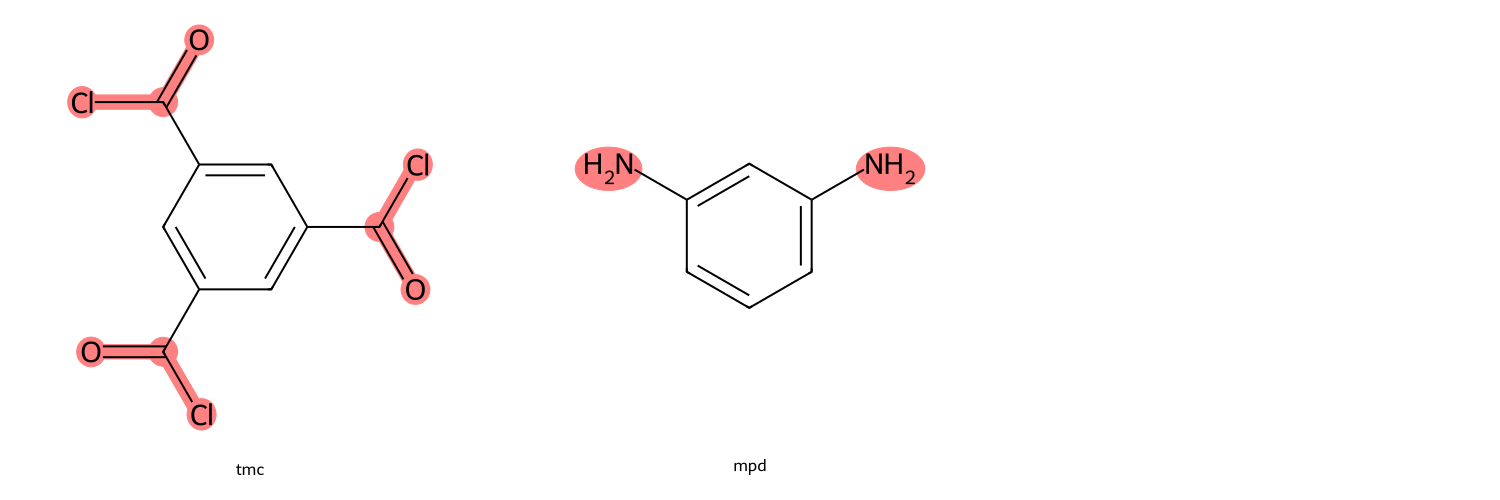

In [6]:
img = functional_groups_detector.functional_group_highlighted_molecules_image_grid(functional_groups_imgs)
img


### Reaction Detection

This cell identifies possible reactions between the detected functional groups.

- `ReactionDetector()` initializes the reaction detection module.
- `reaction_detector()` analyzes the detected functional groups and generates possible reaction instances.
- `create_reaction_image_grid()` visualizes the detected reactions in a grid format.

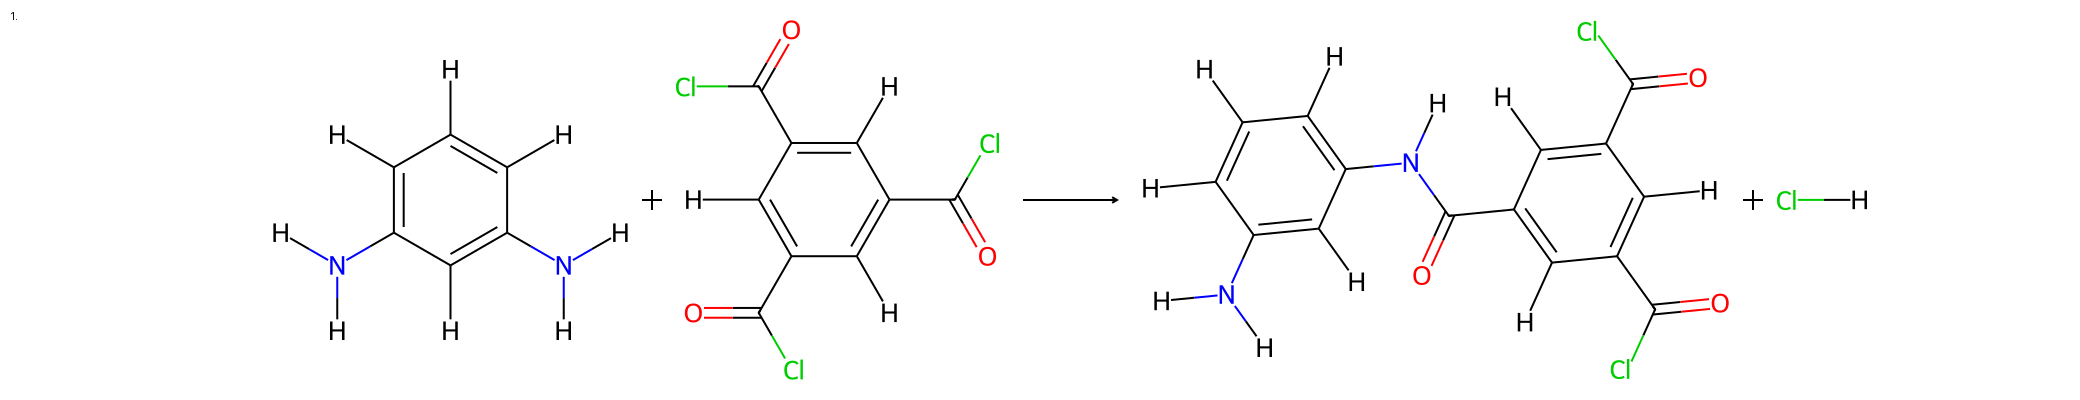

In [ ]:
reaction_detector = ReactionDetector()
reaction_instances = reaction_detector.reaction_detector(functional_groups)
img = reaction_detector.
(reaction_instances)
img

### Reaction Selection

This cell filters and selects the relevant reactions from the detected reaction instances.

- `reaction_selection()` processes the detected reactions.
- It removes invalid or redundant reaction candidates.

In [8]:
selected_reactions = reaction_detector.reaction_selection(reaction_instances)

Only one reaction detected. Automatically selecting it.


### Non-Reactant (Non-Monomer) Detection

This cell identifies molecules that do **not participate in any detected reactions**.

- `NonReactantsDetector()` initializes the detector.
- `non_monomer_detector()` to determine which molecules are non-reactive.
- `non_reactants_to_visualization()` grid to non reactive molecules

If no non-reactant molecules are detected, this stage is **automatically skipped**, and the workflow continues without generating any visualization.

ID: 3, Name: ethanol, SMILES: CCO
ID: 4, Name: data_4, SMILES: CCN


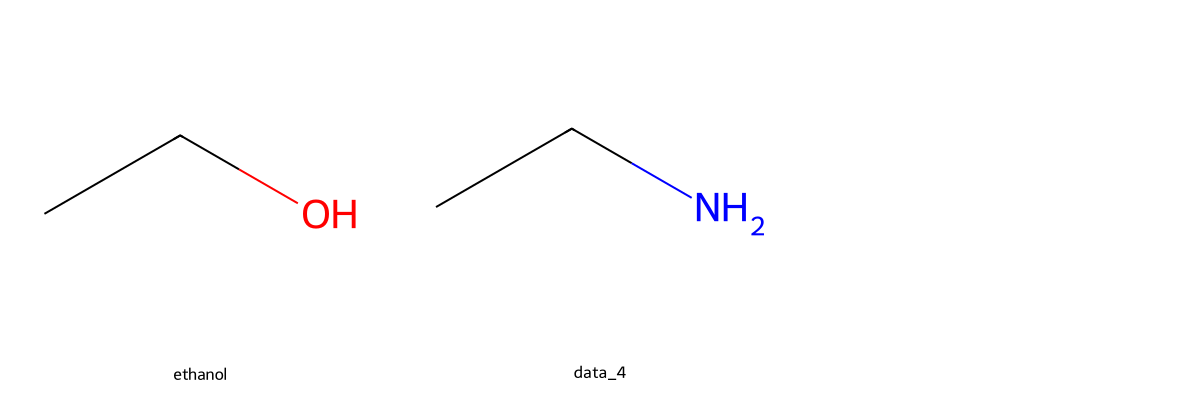

In [9]:
non_monomer_detector = NonReactantsDetector()
non_reactants_list = non_monomer_detector.non_monomer_detector(validated_inputs, selected_reactions)
img_non_reactants = non_monomer_detector.non_reactants_to_visualization(non_reactants_list)
img_non_reactants

### Update Inputs After Non-Reactant Filtering

This cell updates the validated inputs after identifying non-reactive molecules.

- `non_reactant_selection()` removes or marks molecules that do not participate in any reactions.
- The resulting `updated_inputs` contains the filtered set of monomers that will be used in the next stages of the workflow.

If no non-reactants were detected in the previous step, the inputs remain unchanged.

In [10]:
updated_inputs = non_monomer_detector.non_reactant_selection(validated_inputs, non_reactants_list)


Selection Guide for Non-Reactant Monomers:
- N: Discard all non-reactant monomers from the simulation.
- A: Retain all non-reactant monomers in the simulation.
- S: Select specific non-reactant monomers to retain. You will be prompted 
to enter the IDs of the monomers you wish to keep, separated by commas.
Example: If you want to keep monomers with IDs 1 and 3, you would enter: 1,3
              
The following monomers do not participate in any detected reactions:
ID: 3, Name: ethanol, SMILES: CCO
ID: 4, Name: data_4, SMILES: CCN
Invalid input. Please enter N, A, or S.


In [11]:
%%capture captured_output
# execute_pipeline may live in the same module as ReactionTemplatePipeline; import if needed.
from AutoREACTER.reaction_template_builder.run_reaction_template_pipeline import execute_pipeline

execute_pipeline(
    detected_reactions=detected_reactions,
    retain_smiles=non_monomers,
    cache=cache_dir,
)


ImportError: cannot import name 'execute_pipeline' from 'AutoREACTER.reaction_template_builder.run_reaction_template_pipeline' (/mnt/c/Users/Janitha/Documents/AutoREACTER/AutoREACTER/reaction_template_builder/run_reaction_template_pipeline.py)

In [12]:
from pathlib import Path

with open(Path(cache_dir) / "output.txt", "w") as f:
    f.write(captured_output.stdout)

print(f"Output written to {Path(cache_dir) / 'output.txt'}")


Output written to /mnt/c/Users/Janitha/Documents/AutoREACTER/cache/00_cache/output.txt
